In [1]:
import pandas as pd

In [2]:
# load epigenomics ranked genes list
epi_list = pd.read_csv("/home/daffa/Work/2026/thesis/results/ranked_genes_lists/EPI-hyper_SBC10_genes.tsv", sep="\t")
epi_list

,gene_label,diff.Methy,direction,feature,chr,start,end
0,LOC110429559,0.569634,hyper_SBC10,promoter,NC_012877.2,62259132,62259457
1,LOC8078501,0.553901,hyper_SBC10,promoter,NC_012872.2,4999356,4999671
2,LOC8065454,0.517275,hyper_SBC10,promoter,NC_012879.2,5918754,5919106
3,LOC8054506,0.494550,hyper_SBC10,promoter,NC_012871.2,550353,550569
4,LOC8054594,0.485170,hyper_SBC10,promoter,NC_012871.2,55481056,55481230
...,...,...,...,...,...,...,...
4957,LOC8080347,0.025274,hyper_SBC10,promoter,NC_012875.2,46116188,46121186
4958,LOC8080348,0.025274,hyper_SBC10,promoter,NC_012875.2,46116188,46121186
4959,LOC110434324,0.016510,hyper_SBC10,promoter,NC_012873.2,40579174,40580588
4960,LOC8064443,0.013313,hyper_SBC10,promoter,NC_012870.2,62084043,62084532


In [3]:
# load genomics ranked genes list (currently only from SnpEff)
IMPACT_ORDER = ["HIGH", "MODERATE", "LOW", "MODIFIER"]
IMPACT_SCORE = {"HIGH": 1.0, "MODERATE": 2/3, "LOW": 1/3, "MODIFIER": 0.0}
BASE = "/home/daffa/Work/2026/thesis/results/private_variants_annotated"
GENE_INFO = "/home/daffa/Work/2026/thesis/resources/NCBI_FTP/gene_info_4558"

df = pd.read_csv(f"{BASE}/SBC10.private.annotated.tsv", sep="\t", usecols=["impact", "gene_name"])
df = df[df["gene_name"].str.startswith("SORBI", na=False)]
df["impact"] = pd.Categorical(df["impact"], categories=IMPACT_ORDER, ordered=True)

genomics_sbc10 = (
    df.groupby("gene_name")["impact"].min()
    .reset_index()
    .rename(columns={"gene_name": "gene", "impact": "impact"})
    .sort_values(["impact", "gene"])
    .reset_index(drop=True)
)
genomics_sbc10["impact_score"] = genomics_sbc10["impact"].map(IMPACT_SCORE)

# SORBI → LOC conversion
gene_info = pd.read_csv(GENE_INFO, sep="\t", usecols=["Symbol", "LocusTag"])
sorbi_to_loc = gene_info.set_index("LocusTag")["Symbol"].to_dict()
genomics_sbc10["gene_label"] = genomics_sbc10["gene"].map(sorbi_to_loc)

genomics_sbc10

,gene,impact,impact_score,gene_label
0,SORBI_3001G005200,HIGH,1.0,LOC110436541
1,SORBI_3001G005400,HIGH,1.0,NaN
2,SORBI_3001G015000,HIGH,1.0,LOC8060885
3,SORBI_3001G023600,HIGH,1.0,LOC8080197
4,SORBI_3001G027500,HIGH,1.0,NaN
...,...,...,...,...
37738,SORBI_3010G279450,MODIFIER,0.0,LOC8066399
37739,SORBI_3010G279700,MODIFIER,0.0,LOC8066401
37740,SORBI_3010G279800,MODIFIER,0.0,LOC8069250
37741,SORBI_3010G280100,MODIFIER,0.0,LOC8069251


In [4]:
# merge epigenomics and genomics on LOC gene label
merged = (
    genomics_sbc10[["gene_label", "impact", "impact_score"]]
    .dropna(subset=["gene_label"])
    .merge(epi_list[["gene_label", "diff.Methy"]], on="gene_label")
)
merged["impact"] = pd.Categorical(merged["impact"], categories=IMPACT_ORDER, ordered=True)
print(f"{len(merged)} genes in common across both layers")
merged

2796 genes in common across both layers


,gene_label,impact,impact_score,diff.Methy
0,LOC8079693,HIGH,1.0,0.200143
1,LOC8062208,HIGH,1.0,0.163838
2,LOC8064894,HIGH,1.0,0.187209
3,LOC8058776,HIGH,1.0,0.150938
4,LOC8082341,HIGH,1.0,0.123915
...,...,...,...,...
2791,LOC8069226,MODIFIER,0.0,0.133590
2792,LOC8069227,MODIFIER,0.0,0.122910
2793,LOC8069231,MODIFIER,0.0,0.163085
2794,LOC8069246,MODIFIER,0.0,0.120572


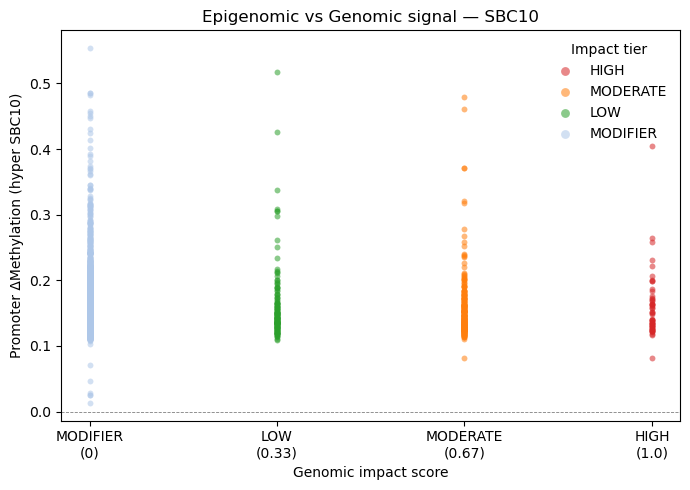

In [7]:
import matplotlib.pyplot as plt
import numpy as np

TIER_COLORS = {"HIGH": "#d62728", "MODERATE": "#ff7f0e", "LOW": "#2ca02c", "MODIFIER": "#aec7e8"}

rng = np.random.default_rng(42)
jitter = rng.uniform(-0.04, 0.04, size=len(merged))

fig, ax = plt.subplots(figsize=(7, 5))

for tier in IMPACT_ORDER:
    mask = merged["impact"] == tier
    ax.scatter(
        merged.loc[mask, "impact_score"],
        merged.loc[mask, "diff.Methy"],
        color=TIER_COLORS[tier], label=tier,
        s=18, alpha=0.55, linewidths=0,
    )

ax.set_xlabel("Genomic impact score")
ax.set_ylabel("Promoter ΔMethylation (hyper SBC10)")
ax.set_title("Epigenomic vs Genomic signal — SBC10")
ax.set_xticks([0, 1/3, 2/3, 1.0])
ax.set_xticklabels(["MODIFIER\n(0)", "LOW\n(0.33)", "MODERATE\n(0.67)", "HIGH\n(1.0)"])
ax.legend(title="Impact tier", frameon=False, markerscale=1.5)
ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")

plt.tight_layout()
plt.savefig("epi_genomics_cooccurrence_SBC10.pdf", dpi=150, bbox_inches="tight")
plt.show()